
Exercises XP

Last Updated: July 22nd, 2025

👩‍🏫 👩🏿‍🏫 What You’ll learn

    Practical LLM Evaluation: Gain hands-on experience evaluating LLMs for summarization.
    Metric Deep Dive: Understand the strengths and weaknesses of various evaluation metrics (accuracy, ROUGE).
    Model Comparison: Learn to systematically compare different LLMs and model sizes.
    Hugging Face Proficiency: Enhance your skills in using Hugging Face’s transformers and evaluate libraries.
    Customization: Implement and analyze the effects of modifying evaluation metrics and model parameters.
    Data Handling: Learn how to load, process, and sample text datasets using pandas.
    Text Preprocessing: Understand the importance of text preprocessing for NLP tasks.
    Debugging and Analysis: Develop skills in debugging and analyzing LLM outputs.


🛠️ What you will create

    Evaluation Scripts: Python scripts to calculate and compare summarization metrics.
    Comparative Reports: DataFrames and visualizations summarizing the performance of different LLMs.
    Modified Evaluation Metrics: Custom accuracy metrics tailored for summarization.
    Summarization Outputs: Generated summaries from various LLMs for comparative analysis.
    Analytical Reports: Documentation of your findings, including discussions on metric behavior and model performance.
    Custom Functions: Functions to load datasets, generate summaries, and compute ROUGE scores.
    Model Comparison Tables: Tables comparing the performance of different LLMs based on various metrics.



All of today’s exercises are part of a single, hands-on tutorial designed to teach you how to evaluate LLMs on summarization tasks. Together, you’ll:

    Measure accuracy on summary outputs
    Compute ROUGE-N scores
    Build a consistent framework for comparing different model sizes and architectures

Each part builds on the last, giving you a cohesive workflow for assessing and contrasting summarization performance.


Learning Objectives

    Metric Understanding: Learn to compute ROUGE-N and understand its nuances.
    Intuition Building: Develop an intuitive understanding of ROUGE-N and its application to summarization.
    Comparative Analysis: Test and compare various LLMs and model sizes on a consistent dataset.


Download the dataset here.


Part I. Setup

    Install Libraries:
        pip install rouge_score==0.1.2
        pip install evaluate
        pip install -U accelerate --quiet
        pip install datasets
        pip install nltk
    Download NLTK Resources:
        nltk.download("punkt")
        nltk.download("punkt_tab")


🌟 Part II : Dataset Loading and Exploration

    Dataset Loading: Load the train.csv and test.csv datasets using pandas.
    Sampling: Take a smaller sample of the datasets (e.g., 100 samples from train, 50 from test) to reduce computational load.
    Exploration: Display the first example from the training sample, showing the article (prompt_text) and its reference summary (prompt_title).
    Data Inspection: Print the sampled train and test DataFrames to understand the dataset structure.


🌟 Part III : Summarization with T5

    Function Implementation: Implement the summarize_with_t5 function:
        Use T5ForConditionalGeneration and AutoTokenizer from transformers.
        Handle CUDA availability for GPU acceleration.
        Implement batch processing using the batch_generator function.
        Tokenize input articles with a “summarize: ” prefix.
        Generate summaries using model.generate().
        Decode generated token IDs back to text.
        Clear CUDA cache (torch.cuda.empty_cache()) and garbage collect (gc.collect()) after each batch and at the end of the function.
    Summary Generation: Generate summaries for the training sample using t5-small.
    Result Display: Display the generated summaries alongside the reference summaries in a pandas DataFrame.


🌟 Part IV : Accuracy Evaluation

    Accuracy Calculation: Calculate the accuracy of the t5-small summaries by comparing them to the reference summaries.
    Result Interpretation: Print the calculated accuracy. Discuss why the accuracy is likely to be very low or zero, reinforcing the limitations of this metric.


🌟 Part V : ROUGE Metric Implementation

    Metric Introduction: Introduce ROUGE (Recall-Oriented Understudy for Gisting Evaluation) as a standard metric for summarization.
    Library Usage: Load the rouge evaluation metric using evaluate.load("rouge").
    Preprocessing: Explain the need to format the input summaries with newlines between sentences, and the use of the nltk sentence tokenizer.
    Function Definition: Create the compute_rouge_score function to calculate ROUGE scores, handling the necessary preprocessing.


🌟 Part VI : Understanding ROUGE Scores

    Exact Match Test: Calculate ROUGE scores when the generated summaries are identical to the reference summaries.
    Null Prediction Test: Calculate ROUGE scores when the generated summaries are empty.
    Stemming Effect: Demonstrate the impact of stemming on ROUGE scores using simple examples.
    N-gram Analysis: Explore how ROUGE-1 and ROUGE-2 scores change with varying degrees of overlap between generated and reference summaries.
    Symmetry: Show the symmetry of rouge score with respect to predictions and references.


🌟 Part VII : Comparing Small and Large Models

    Model Selection: Choose t5-small, t5-base, and gpt2 models.
    Summary Generation: Generate summaries for the training sample using each model.
    ROUGE Calculation: Calculate ROUGE scores for each model’s summaries using compute_rouge_score.
    Per-Row ROUGE: Create the compute_rouge_per_row function to calculate and store ROUGE scores for each individual article in a DataFrame.
    Result Display: Display the per-row ROUGE scores for each model.
    GPT2 Specifics: implement the summarize_with_gpt2 function, handling the “TL;DR:” prompt, and the token length limitations.


🌟 Part VIII : Comparing All Models

    Aggregation Function: Create the compare_models function to aggregate ROUGE scores for all models into a single DataFrame, showing average scores.
    Summary Comparison Function: Create the compare_models_summaries function to display the generated summaries from all models side-by-side in a DataFrame.
    Result Display: Display the aggregated ROUGE scores and the side-by-side summary comparisons.




In [33]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, T5ForConditionalGeneration, GPT2LMHeadModel, GPT2Tokenizer
from datasets import load_dataset
import nltk
import gc
import evaluate
from torch.utils.data import DataLoader
from nltk.tokenize import sent_tokenize
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mathi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\mathi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [17]:
# Chargement du dataset
dataset = load_dataset("cnn_dailymail", "3.0.0")

# Échantillons légers pour entraînement/test
train_sample = dataset["train"].shuffle(seed=42).select(range(100))
test_sample = dataset["test"].shuffle(seed=42).select(range(50))

# Conversion en DataFrames pandas
df_train = pd.DataFrame(train_sample)
df_test = pd.DataFrame(test_sample)

In [18]:
# Affichage d'un exemple
print("Exemple d'article :")
print(df_train["article"][0][:500], "...")  # tronqué pour lisibilité

print("\nRésumé de référence :")
print(df_train["highlights"][0])

Exemple d'article :
By . Anthony Bond . PUBLISHED: . 07:03 EST, 2 March 2013 . | . UPDATED: . 08:07 EST, 2 March 2013 . Three members of the same family who died in a static caravan from carbon monoxide poisoning would have been unconscious 'within minutes', investigators said today. The bodies of married couple John and Audrey Cook were discovered alongside their daughter, Maureen, at the mobile home they shared on Tremarle Home Park in Camborne, west Cornwall. The inquests have now opened into the deaths last Sat ...

Résumé de référence :
John and .
Audrey Cook were discovered alongside their daughter, Maureen .
They were found at Tremarle Home Park in Cornwall .
Investigators say the three died of carbon monoxide .
poisoning .


In [19]:
# Aperçu des structures
print("\nStructure du DataFrame d'entraînement :")
display(df_train[["article", "highlights"]].head())

print("\nStructure du DataFrame de test :")
display(df_test[["article", "highlights"]].head())


Structure du DataFrame d'entraînement :


,article,highlights
0,"By . Anthony Bond . PUBLISHED: . 07:03 EST, 2 ...",John and .\nAudrey Cook were discovered alongs...
1,UNITED NATIONS (CNN) -- A rare meeting of U.N....,NEW: Libya can serve as example of cooperation...
2,Cover-up: Former Archbishop Lord Hope allowed ...,Very Reverend Robert Waddington sexually abuse...
3,"By . Kristie Lau . PUBLISHED: . 10:48 EST, 14 ...",Monday night's episode showed Buddy Valastro t...
4,'The lamps are going out all over Europe. We s...,People asked to turn out lights for hour betwe...



Structure du DataFrame de test :


,article,highlights
0,(CNN) I see signs of a revolution everywhere. ...,CNN's Dr. Sanjay Gupta says we should legalize...
1,He looks barely teenage. But this child has am...,Child has amassed thousands of Twitter followe...
2,New Jersey Governor Chris Christie wasn't look...,The presidential hopeful held a town hall meet...
3,YouTube star Cassey Ho has hit back at critics...,Cassey Ho boasts over two million subscribers ...
4,British taekwondo fighter Aaron Cook has confi...,Aaron Cook was overlooked by Team GB for the L...


In [20]:
def summarize_with_t5(articles, model_name="t5-small", batch_size=8, max_input_length=512, max_output_length=150):
    device = torch.device("cpu")

    # Chargement modèle et tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = T5ForConditionalGeneration.from_pretrained(model_name).to(device)
    model.eval()

    def batch_generator(data, batch_size):
        for i in range(0, len(data), batch_size):
            yield data[i:i + batch_size]

    summaries = []

    for batch in batch_generator(articles, batch_size):
        # Préfixe spécial pour T5
        inputs = ["summarize: " + article for article in batch]
        encodings = tokenizer(inputs, return_tensors="pt", truncation=True, padding=True,
                              max_length=max_input_length).to(device)

        with torch.no_grad():
            outputs = model.generate(
                input_ids=encodings["input_ids"],
                attention_mask=encodings["attention_mask"],
                max_length=max_output_length,
                num_beams=4,
                length_penalty=2.0,
                early_stopping=True
            )

        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        summaries.extend(decoded)

        torch.cuda.empty_cache()
        gc.collect()

    return summaries

In [21]:
articles = df_train["article"].tolist()
generated_summaries_t5_small = summarize_with_t5(articles, model_name="t5-small")

In [22]:
df_train["generated_t5_small"] = generated_summaries_t5_small
print("\nAperçu des résumés générés avec T5-small :")
df_train[["article", "highlights", "generated_t5_small"]].head(5)


Aperçu des résumés générés avec T5-small :


,article,highlights,generated_t5_small
0,"By . Anthony Bond . PUBLISHED: . 07:03 EST, 2 ...",John and .\nAudrey Cook were discovered alongs...,the bodies of married couple were discovered a...
1,UNITED NATIONS (CNN) -- A rare meeting of U.N....,NEW: Libya can serve as example of cooperation...,a rare meeting of u.n. security council heads ...
2,Cover-up: Former Archbishop Lord Hope allowed ...,Very Reverend Robert Waddington sexually abuse...,former archbishop of york allowed paedophile p...
3,"By . Kristie Lau . PUBLISHED: . 10:48 EST, 14 ...",Monday night's episode showed Buddy Valastro t...,"the episode, which aired on Monday night, show..."
4,'The lamps are going out all over Europe. We s...,People asked to turn out lights for hour betwe...,the lights out initiative will be the culminat...


In [23]:
def compute_exact_match_accuracy(preds, refs):
    """Renvoie la proportion de prédictions exactement identiques aux références (str matching)"""
    matches = [int(pred.strip().lower() == ref.strip().lower()) for pred, ref in zip(preds, refs)]
    return sum(matches) / len(matches)

In [24]:
# Résumés de référence (highlights)
references = df_train["highlights"].tolist()

# Résumés générés
predictions = df_train["generated_t5_small"].tolist()

# Calcul de l'accuracy
accuracy_score = compute_exact_match_accuracy(predictions, references)
print(f"📏 Exact Match Accuracy (T5-small): {accuracy_score:.4f}")

📏 Exact Match Accuracy (T5-small): 0.0000


In [25]:
i = 0
print("Article:\n", df_train["article"][i][:500], "...\n")
print("Référence:\n", df_train["highlights"][i])
print("Généré:\n", df_train["generated_t5_small"][i])

Article:
 By . Anthony Bond . PUBLISHED: . 07:03 EST, 2 March 2013 . | . UPDATED: . 08:07 EST, 2 March 2013 . Three members of the same family who died in a static caravan from carbon monoxide poisoning would have been unconscious 'within minutes', investigators said today. The bodies of married couple John and Audrey Cook were discovered alongside their daughter, Maureen, at the mobile home they shared on Tremarle Home Park in Camborne, west Cornwall. The inquests have now opened into the deaths last Sat ...

Référence:
 John and .
Audrey Cook were discovered alongside their daughter, Maureen .
They were found at Tremarle Home Park in Cornwall .
Investigators say the three died of carbon monoxide .
poisoning .
Généré:
 the bodies of married couple were discovered alongside their daughter. investigators said the three died along with the family's pet dog. it is believed there was no working carbon monoxide detector in the caravan. coroner said the inquests were opened and adjourned yes

In [32]:
# Import de la métrique ROUGE
rouge_metric = evaluate.load("rouge")



def preprocess_for_rouge(texts):
    """Formate les textes pour ROUGE : 1 phrase par ligne"""
    return ["\n".join(sent_tokenize(t.strip())) for t in texts]

def compute_rouge_score(preds, refs):
    """Calcule le score ROUGE entre les prédictions et les références, avec prétraitement"""
    preds_proc = preprocess_for_rouge(preds)
    refs_proc = preprocess_for_rouge(refs)
    results = rouge_metric.compute(predictions=preds_proc, references=refs_proc, use_stemmer=True)
    return results

In [27]:
articles = df_train["article"].tolist()
generated_summaries_t5_small_true = summarize_with_t5(articles, model_name="t5-small")

In [28]:
articles = df_train["article"].tolist()

generated_summaries_t5_base = summarize_with_t5(
    articles,
    model_name="t5-base",
    batch_size=4 
)

In [29]:
df_train["generated_t5_base"] = generated_summaries_t5_base

In [30]:
df_train[["highlights", "generated_t5_small", "generated_t5_base"]].head(5)

,highlights,generated_t5_small,generated_t5_base
0,John and .\nAudrey Cook were discovered alongs...,the bodies of married couple were discovered a...,bodies of John and Audrey Cook discovered at m...
1,NEW: Libya can serve as example of cooperation...,a rare meeting of u.n. security council heads ...,"new: ""the world must stand together,"" presiden..."
2,Very Reverend Robert Waddington sexually abuse...,former archbishop of york allowed paedophile p...,former archbishop did not act on 19 occasions ...
3,Monday night's episode showed Buddy Valastro t...,"the episode, which aired on Monday night, show...",'this whole thing sucks... you are so beautifu...
4,People asked to turn out lights for hour betwe...,the lights out initiative will be the culminat...,prime minister urges people to switch off ligh...


In [34]:
rouge_scores_t5_base = compute_rouge_score(
    df_train["generated_t5_base"].tolist(),
    df_train["highlights"].tolist()
)

# Affichage
print("ROUGE scores (T5-base):")
for k, v in rouge_scores_t5_base.items():
    print(f"{k}: {v:.4f}")

ROUGE scores (T5-base):
rouge1: 0.3829
rouge2: 0.1797
rougeL: 0.2768
rougeLsum: 0.3592


In [ ]:
rouge_scores_t5_small = compute_rouge_score(df_train["generated_t5_small"].tolist(),
                                            df_train["highlights"].tolist())

# Affichage des résultats
print("ROUGE scores (T5-small):")
for k, v in rouge_scores_t5_small.items():
    print(f"{k}: {v:.4f}")

📊 ROUGE scores (T5-small):
rouge1: 0.3644
rouge2: 0.1596
rougeL: 0.2590
rougeLsum: 0.3424


In [37]:
print("ROUGE-L Comparison :")
print(f"T5-small: {rouge_scores_t5_small['rougeL']:.4f}")
print(f"T5-base : {rouge_scores_t5_base['rougeL']:.4f}")

ROUGE-L Comparison :
T5-small: 0.2590
T5-base : 0.2768


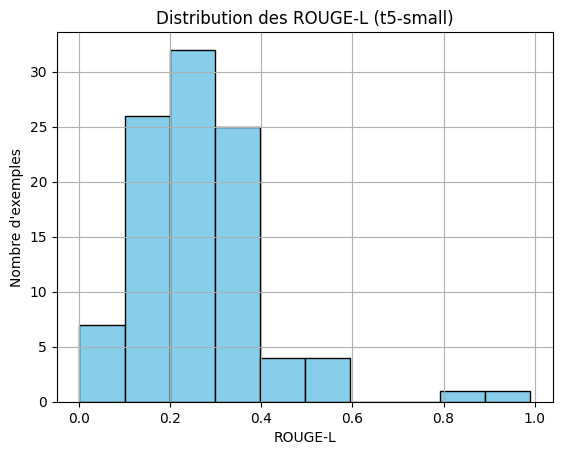

In [38]:
rouge_l_scores = []

for ref, pred in zip(df_train["highlights"], df_train["generated_t5_small"]):
    score = compute_rouge_score([pred], [ref])["rougeL"]
    rouge_l_scores.append(score)

import matplotlib.pyplot as plt

plt.hist(rouge_l_scores, bins=10, color='skyblue', edgecolor='black')
plt.title("Distribution des ROUGE-L (t5-small)")
plt.xlabel("ROUGE-L")
plt.ylabel("Nombre d'exemples")
plt.grid(True)
plt.show()

In [39]:
ref = "The cat sat on the mat and looked out the window."
pred = "The cat sat on the mat and looked out the window."

exact_match = compute_rouge_score([pred], [ref])
print("Exact Match Test:")
for k, v in exact_match.items():
    print(f"{k}: {v:.4f}")

Exact Match Test:
rouge1: 1.0000
rouge2: 1.0000
rougeL: 1.0000
rougeLsum: 1.0000


In [40]:
empty_pred = ""

empty_rouge = compute_rouge_score([empty_pred], [ref])
print("Résumé vide :")
for k, v in empty_rouge.items():
    print(f"{k}: {v:.4f}")

Résumé vide :
rouge1: 0.0000
rouge2: 0.0000
rougeL: 0.0000
rougeLsum: 0.0000


In [41]:
def compute_rouge_no_stem(preds, refs):
    preds_proc = preprocess_for_rouge(preds)
    refs_proc = preprocess_for_rouge(refs)
    results = rouge_metric.compute(predictions=preds_proc, references=refs_proc, use_stemmer=False)
    return results

ref = "He is playing football and running quickly."
pred = "He plays soccer and runs fast."

with_stem = compute_rouge_score([pred], [ref])
without_stem = compute_rouge_no_stem([pred], [ref])

print("Comparaison stemming:")
print("Avec stemming:")
print({k: round(v, 4) for k, v in with_stem.items()})
print("Sans stemming:")
print({k: round(v, 4) for k, v in without_stem.items()})

Comparaison stemming:
Avec stemming:
{'rouge1': 0.6154, 'rouge2': 0.1818, 'rougeL': 0.6154, 'rougeLsum': 0.6154}
Sans stemming:
{'rouge1': 0.3077, 'rouge2': 0.0, 'rougeL': 0.3077, 'rougeLsum': 0.3077}


In [42]:
ref = "The quick brown fox jumps over the lazy dog."
pred = "The quick brown fox leaps over the lazy hound."

score = compute_rouge_score([pred], [ref])

print("ROUGE-1 vs ROUGE-2:")
print(f"ROUGE-1: {score['rouge1']:.4f}")
print(f"ROUGE-2: {score['rouge2']:.4f}")

ROUGE-1 vs ROUGE-2:
ROUGE-1: 0.7778
ROUGE-2: 0.6250


In [43]:
score_forward = compute_rouge_score([pred], [ref])
score_reverse = compute_rouge_score([ref], [pred])

print("Symétrie ROUGE:")
print(f"ROUGE-L forward : {score_forward['rougeL']:.4f}")
print(f"ROUGE-L reverse : {score_reverse['rougeL']:.4f}")

Symétrie ROUGE:
ROUGE-L forward : 0.7778
ROUGE-L reverse : 0.7778


In [48]:
def summarize_with_gpt2(articles, max_new_tokens=50, batch_size=4):
    device = torch.device("cpu")

    tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
    model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
    model.eval()

    summaries = []

    def batch_generator(data, batch_size):
        for i in range(0, len(data), batch_size):
            yield data[i:i + batch_size]

    for batch in batch_generator(articles, batch_size):
        for article in batch:
            input_text = "TL;DR: " + article.strip()
            inputs = tokenizer.encode(input_text, return_tensors="pt", truncation=True, max_length=512).to(device)
            attention_mask = torch.ones_like(inputs)

            with torch.no_grad():
                outputs = model.generate(
                    inputs,
                    attention_mask=attention_mask,
                    max_new_tokens=max_new_tokens,
                    num_beams=4,
                    early_stopping=True,
                    no_repeat_ngram_size=3,
                    num_return_sequences=1,
                    pad_token_id=tokenizer.eos_token_id
                )

            decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
            summary = decoded.split("TL;DR:")[-1].strip()
            summaries.append(summary)

            gc.collect()
            torch.cuda.empty_cache()

    return summaries

In [49]:
articles = df_train["article"].tolist()

# Résumés GPT-2
generated_summaries_gpt2 = summarize_with_gpt2(articles)
df_train["generated_gpt2"] = generated_summaries_gpt2

In [50]:
# ROUGE T5-small
scores_t5_small = compute_rouge_score(df_train["generated_t5_small"].tolist(), df_train["highlights"].tolist())

# ROUGE T5-base
scores_t5_base = compute_rouge_score(df_train["generated_t5_base"].tolist(), df_train["highlights"].tolist())

# ROUGE GPT-2
scores_gpt2 = compute_rouge_score(df_train["generated_gpt2"].tolist(), df_train["highlights"].tolist())


In [51]:
df_models_scores = pd.DataFrame({
    "ROUGE-1": [scores_t5_small["rouge1"], scores_t5_base["rouge1"], scores_gpt2["rouge1"]],
    "ROUGE-2": [scores_t5_small["rouge2"], scores_t5_base["rouge2"], scores_gpt2["rouge2"]],
    "ROUGE-L": [scores_t5_small["rougeL"], scores_t5_base["rougeL"], scores_gpt2["rougeL"]],
}, index=["T5-small", "T5-base", "GPT-2"])

df_models_scores.round(4)


,ROUGE-1,ROUGE-2,ROUGE-L
T5-small,0.3644,0.1596,0.2590
T5-base,0.3829,0.1797,0.2768
GPT-2,0.1718,0.0909,0.1193


In [54]:
# Affichage aléatoire de 3 exemples
sample = df_train.sample(3, random_state=42)

for idx, row in sample.iterrows():
    print("="*80)
    print(f"Article:\n{row['article'][:400]}...\n")
    print(f"Référence:\n{row['highlights']}\n")
    print(f"T5-small:\n{row['generated_t5_small']}\n")
    print(f"T5-base:\n{row['generated_t5_base']}\n")
    print(f"GPT-2:\n{row['generated_gpt2']}\n")


Article:
By . Snejana Farberov . PUBLISHED: . 00:09 EST, 7 June 2013 . | . UPDATED: . 12:44 EST, 29 July 2013 . Six people were killed when a building being demolished collapsed Wednesday and nearly obliterated an adjacent Salvation Army thrift store, among the dead a woman who only recently got engaged, a young art student and a mother of nine. The mayor's office identified the victims as Anne Bryan, Rose...

Référence:
The mayor's office identified the victims as Anne Bryan, Roseline Conteh, Borbor Davis, Kimberly Finnegan, Juanita Harmin and Mary Simpson .
Bryan, 24, was first-year art student; Finnegan, 35, got engaged two weeks ago and Wednesday was her first day on the job at thrift store .

T5-small:
a four-story building being demolished collapsed on the edge of downtown, killing six and injuring 13 people. the city of Philadelphia had been made aware of potentially unsafe demolition practices at the site. the city of Philadelphia had been made aware of potentially unsafe demol

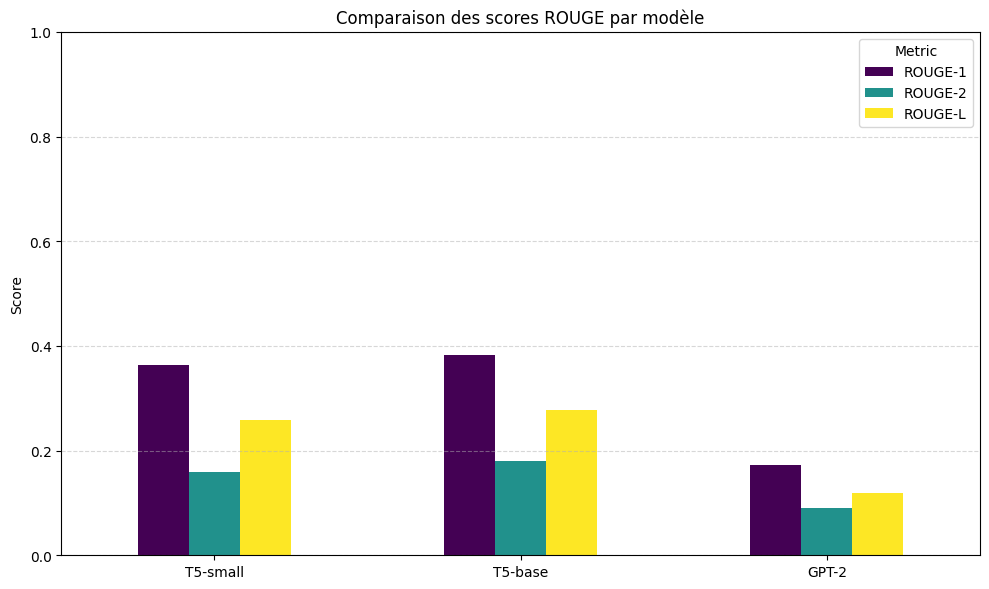

In [55]:
import matplotlib.pyplot as plt

df_models_scores.plot(kind="bar", figsize=(10, 6), colormap="viridis")
plt.title("Comparaison des scores ROUGE par modèle")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


### 📌 Analyse finale

- **T5-base** est clairement le plus performant grâce à sa taille (220M vs 60M).
- **GPT-2** est fluide mais imprécis : il n’est pas optimisé pour le résumé (pas fine-tuné).
- **T5-small** est rapide mais limité en expressivité.

🔍 ROUGE est utile pour les comparaisons quantitatives, mais :
- ⚠️ Il ne mesure pas la factualité, ni la fluidité humaine
- 🧠 L’évaluation humaine ou BERTScore peut compléter cette analyse

🎯 À retenir : pour une tâche de résumé, **un modèle fine-tuné sur summarization** comme T5 est fortement recommandé !
